# AI-driven ChemE car Competition

## Manual tunning and control


为了更加可靠的识别颜色，这里使用了HSV颜色代码，HSV的数值代表以下意思：H (Hue): 0–360 degrees；S (Saturation): 0–100 (percent)；V (Value): 0–100 (percent)。

可以使用以下链接挑选颜色：

颜色挑选：https://colorpicker.me/#e5fe1d

上传图片挑选颜色：https://redketchup.io/color-picker

HSV lower color里面的每一项数值需要对应小于HSV upper color，比如hsv_lower = [200, 0 ,0], hsv_upper = [200, 100 ,100]。但从定义上将S和V的数值大意味着更鲜艳更亮的颜色，所以在碘钟反应中选择的浅黄应该对应hsv_upper，深黄对应比如hsv_lower。

Color change threshold指所指定区域内有多少比例的像素处于设定的颜色范围内

In [1]:
from camera_control import CameraControl
from MKSMotor_USB import MKSMotor, MotorControlUI
import time
import ipywidgets as widgets
from IPython.display import display
import cv2
import threading

# CameraControl
cam_control = CameraControl(digit_cam_id=2, color_cam_id=1)
cam_control.display_UI()

# Configure serial port parameters, Linux/MacOS starts with dev/tty., Windows uses "COM3, COM5" etc.
port="COM7"
motor = MKSMotor(port=port)  # Motor initialization
motor_ui = MotorControlUI(motor)
motor_ui.display_controls()


Output()

## Ready to go competition
### Step 1: Configure your MNIST algorithm
请先加载你的MNIST模型，请使用作业中的格式，以便加载

In [2]:
# 加载model.py中训练的MNIST模型
from model import NeuralNetwork

# 加载训练好的模型（使用.pkl格式）
mnist_model = NeuralNetwork.load_model("model_only_right.pkl")

模型已从 model_only_right.pkl 加载


Test your model before going forward!

在这里先测试一下你的模型，以确保模型正常工作。

模型已从 model_only.pkl 加载
[0]
[1]
[2]
[3]
[4]
[5]
[6]
[7]
[8]
[9]
Your model correctly predicted the '0' digit.


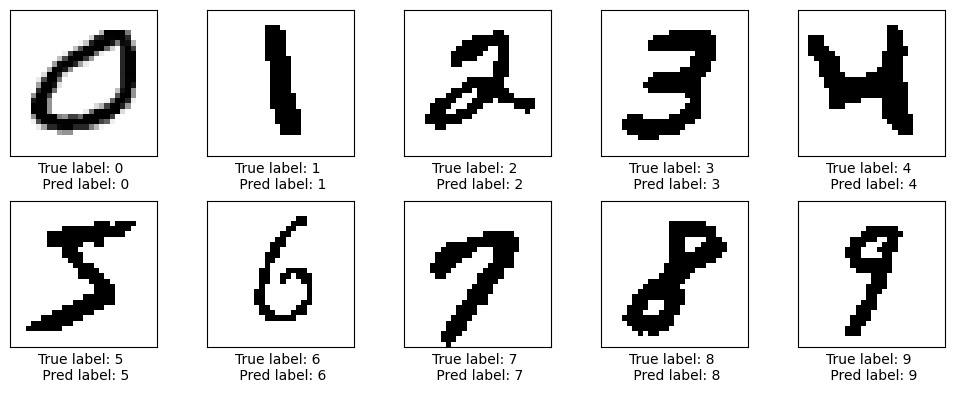

Total samples: 3167
Correct predictions: 3167
Accuracy: 1.0000 (100.00%)
Errors saved to prediction_errors.csv, total errors: 0

错误预测比例（按真实标签）:
----------------------------------------
Label 0: 0/3 = 0.0000 (0.00%)
Label 1: 0/12 = 0.0000 (0.00%)
Label 2: 0/104 = 0.0000 (0.00%)
Label 3: 0/161 = 0.0000 (0.00%)
Label 4: 0/355 = 0.0000 (0.00%)
Label 5: 0/561 = 0.0000 (0.00%)
Label 6: 0/689 = 0.0000 (0.00%)
Label 7: 0/426 = 0.0000 (0.00%)
Label 8: 0/819 = 0.0000 (0.00%)
Label 9: 0/37 = 0.0000 (0.00%)
----------------------------------------


np.float64(1.0)

In [ ]:
from mnist_model_test import random_read_mnist_csv, plot_images, evaluate_full_dataset
from model import NeuralNetwork
import matplotlib.pyplot as plt

csv_file = "labeled_data_with0.csv"  
selected_images, selected_labels = random_read_mnist_csv(csv_file)

# ------------ 在这里替换你的模型 --------------- #
mnist_model = NeuralNetwork.load_model("model_only_right.pkl")
# ------------ 在这里替换你的模型 --------------- #

pred_labels = []
for img in selected_images:
    # model.py 的 predict 需要 reshape(1, -1)
    pred = mnist_model.predict(img.reshape(1, -1))
    print(pred)
    pred_labels.append(pred[0])

if pred_labels[0] == selected_labels[0]:
    print(f"Your model correctly predicted the '{selected_labels[0]}' digit.")
else:
    print(f"Your model failed to predict. Expected {selected_labels[0]}, got {pred_labels[0]}")
    
plot_images(selected_images, selected_labels, pred_labels)

evaluate_full_dataset(mnist_model, csv_file, "prediction_errors.csv")

### Step 2: Run for target digit

In [3]:
from contest_helper_code import preflight_check, DigitContestRunner

preflight_check(cam_control, motor, mnist_model=globals().get("mnist_model"), step=2)
runner1 = DigitContestRunner(motor, cam_control, motor_ui, mnist_model)
runner1.display()

⚠️  Cannot start Step 2. Fix the following issues:

  ❌ Cameras are not running — click 'Start Cameras' in the setup cell.


RuntimeError: Pre-flight check failed — see messages above.

### Step 3: Configure your chemistry timing algorithm

已处理: 200 (C:\Users\abc\Desktop\ml\excel\200.xlsx)
已处理: 280 (C:\Users\abc\Desktop\ml\excel\280.xlsx)
已处理: 400 (C:\Users\abc\Desktop\ml\excel\400.xlsx)
已处理: 440 (C:\Users\abc\Desktop\ml\excel\440.xlsx)
已处理: 500 (C:\Users\abc\Desktop\ml\excel\500.xlsx)
已处理: 600 (C:\Users\abc\Desktop\ml\excel\600.xlsx)
已处理: 725 (C:\Users\abc\Desktop\ml\excel\725.xlsx)
已处理: 765 (C:\Users\abc\Desktop\ml\excel\765.xlsx)
已处理: 800 (C:\Users\abc\Desktop\ml\excel\800.xlsx)
已处理: 200 (C:\Users\abc\Desktop\ml\excel\200.xlsx)
已处理: 280 (C:\Users\abc\Desktop\ml\excel\280.xlsx)
已处理: 400 (C:\Users\abc\Desktop\ml\excel\400.xlsx)
已处理: 440 (C:\Users\abc\Desktop\ml\excel\440.xlsx)
已处理: 500 (C:\Users\abc\Desktop\ml\excel\500.xlsx)
已处理: 600 (C:\Users\abc\Desktop\ml\excel\600.xlsx)
已处理: 725 (C:\Users\abc\Desktop\ml\excel\725.xlsx)
已处理: 765 (C:\Users\abc\Desktop\ml\excel\765.xlsx)
已处理: 800 (C:\Users\abc\Desktop\ml\excel\800.xlsx)


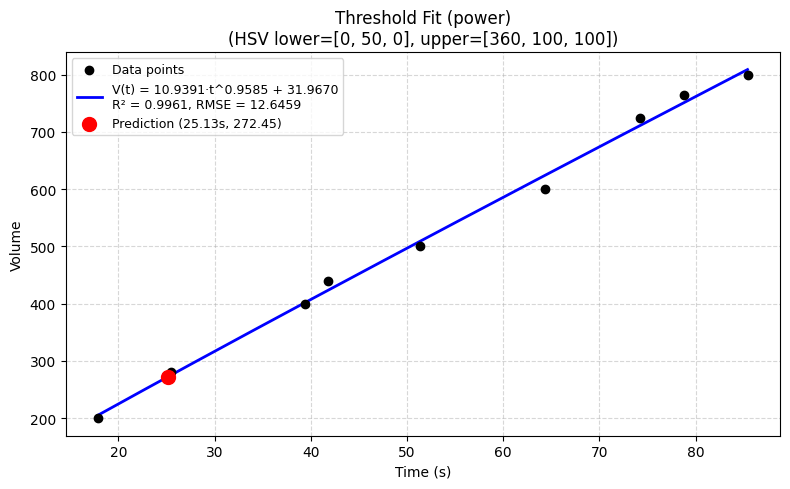

TypeError: 'float' object is not subscriptable

In [11]:
from fit import batch_fit_color_curves, fit_threshold_curve, fit_power_range
import numpy as np

folder = r"C:\Users\abc\Desktop\ml\excel"
all_curve = batch_fit_color_curves(folder)

volume_needed = fit_threshold_curve(
    time=25.13,
    folder = folder,
    lower_hsv=[0, 50, 0],
    upper_hsv=[360, 100, 100],
)
print(f"阈值模型预测用量: {volume_needed['prediction']:.2f}")

### Step 4: Run for target timing

In [ ]:
from contest_helper_code import preflight_check, ColorContestRunner

preflight_check(cam_control, motor, step=4)
runner2 = ColorContestRunner(motor, cam_control, motor_ui)
runner2.display()

### Step 5: Results calculation

In [10]:
import pandas as pd
import os

xlsx_file = 'contest_results.xlsx'
header = ['step2_pos', 'step4_pos', 'diff', 'step2_time', 'step4_time']

if runner1.stop_pos is None or runner2.stop_pos is None:
    print("You must run each step sequentially before calculating your contest results!")
else:
    diff = abs(runner2.stop_pos - runner1.stop_pos)
    print(f"Step 2 stop position : {runner1.stop_pos:.2f} mm  (elapsed {runner1.stop_elapsed:.2f} s)")
    print(f"Step 4 stop position : {runner2.stop_pos:.2f} mm  (elapsed {runner2.stop_elapsed:.2f} s)")
    print(f"Difference between two runs: {diff:.2f} mm")
    
    # 保存到Excel文件
    new_row = pd.DataFrame([[runner1.stop_pos, runner2.stop_pos, diff, 
                             runner1.stop_elapsed, runner2.stop_elapsed]], 
                           columns=header)
    if os.path.exists(xlsx_file):
        old_df = pd.read_excel(xlsx_file)
        new_df = pd.concat([old_df, new_row], ignore_index=True)
    else:
        new_df = new_row
    new_df.to_excel(xlsx_file, index=False)
    print(f"Results saved to {xlsx_file}")

Step 2 stop position : 247.51 mm  (elapsed 73.81 s)
Step 4 stop position : 263.63 mm  (elapsed 78.61 s)
Difference between two runs: 16.13 mm
Results saved to contest_results.xlsx
